# M-N Interaction Diagram Tutorial

This notebook demonstrates the complete functionality of the M-N interaction diagram implementation using fiber-based strain compatibility analysis per Eurocode 2.

## Table of Contents

1. [Setup and Imports](#setup)
2. [Create Materials](#materials)
3. [Create RC Section with Reinforcement](#section)
4. [Create M-N Interaction Diagram](#create-diagram)
5. [Generate Complete Diagram](#generate-diagram)
6. [Visualize the M-N Curve](#visualize)
7. [Check Capacity for Applied Loads](#check-capacity)
8. [Get Moment Capacity at Specific Axial Force](#get-capacity)
9. [Compare Different Concrete Models](#compare-concrete)
10. [Compare Steel Models](#compare-steel)
11. [Effect of Mesh Resolution](#mesh-resolution)
12. [Advanced: T-Beam Section](#t-beam)
13. [ULS Persistent/Transient vs. Accidental Limit States](#uls-comparison)

## 1. Setup and Imports <a id='setup'></a>

First, let's import all necessary modules and set up plotting.

In [19]:
# Setup: Add project root to Python path
import sys
from pathlib import Path

# Notebook is in examples/ subdirectory, go up one level to project root
project_root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"[OK] Added to Python path: {project_root}")
print(f"[OK] Can now import 'materials' package")


[OK] Added to Python path: c:\Users\user\Repo\Scripts\section_design_checks
[OK] Can now import 'materials' package


In [20]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

# Materials library imports
from materials.reinforced_concrete.materials import ConcreteMaterial, Rebar
from materials.reinforced_concrete.geometry import (
    create_rectangular_section,
    create_circular_section,
    create_linear_rebar_layer,
    create_rectangular_perimeter_rebars,
    RCSection,
)
from materials.reinforced_concrete.analysis import create_interaction_diagram
from materials.core.geometry import Point2D
from shapely.geometry import Polygon

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 10

print("[OK] Imports successful")

[OK] Imports successful


## 2. Create Materials <a id='materials'></a>

Define concrete and reinforcing steel materials according to Eurocode 2.

In [21]:
# Create C30/37 concrete
concrete = ConcreteMaterial(
    grade="C30/37",
    gamma_c=1.5,      # Partial safety factor
    alpha_cc=0.85,     # Long-term strength reduction factor
)

print("Concrete Material Properties:")
print(f"  Grade: {concrete.grade}")
print(f"  f_ck = {concrete.f_ck:.1f} MPa (characteristic strength)")
print(f"  f_cd = {concrete.f_cd:.1f} MPa (design strength)")
print(f"  E_cm = {concrete.E_cm:.0f} MPa (elastic modulus)")
print(f"  ɛ_c2 = {concrete.epsilon_c2:.5f} (peak strain)")
print(f"  ɛ_cu2 = {concrete.epsilon_cu2:.5f} (ultimate strain)")
print()

# Create B500B reinforcing steel
rebar_20 = Rebar(
    grade="B500B",
    diameter=20,      # mm
)

print("Reinforcement Properties:")
print(f"  Grade: {rebar_20.grade}")
print(f"  Diameter: ϕ•{rebar_20.diameter} mm")
print(f"  Area: {rebar_20.area:.1f} mm²")
print(f"  f_yk = {rebar_20.f_yk:.1f} MPa (characteristic strength)")
print(f"  f_yd = {rebar_20.f_yd:.1f} MPa (design strength)")
print(f"  E_s = {rebar_20.E_s:.0f} MPa (elastic modulus)")

Concrete Material Properties:
  Grade: C30/37
  f_ck = 30.0 MPa (characteristic strength)
  f_cd = 17.0 MPa (design strength)
  E_cm = 32837 MPa (elastic modulus)
  ɛ_c2 = 0.00200 (peak strain)
  ɛ_cu2 = 0.00350 (ultimate strain)

Reinforcement Properties:
  Grade: B500B
  Diameter: ϕ•20 mm
  Area: 314.2 mm²
  f_yk = 500.0 MPa (characteristic strength)
  f_yd = 434.8 MPa (design strength)
  E_s = 200000 MPa (elastic modulus)


## 3. Create RC Section with Reinforcement <a id='section'></a>

Create a 300Ã—500 mm rectangular beam section with bottom and top reinforcement.

In [22]:
# Create rectangular section (centred at origin)
section_width = 300  # mm
section_height = 500  # mm

# Sections are created with their centre at (0,0)

section = create_rectangular_section(
    width=section_width,
    height=section_height,
    section_name="Example Beam",
)

# ϕ20 => radius = 10
cover = 50
r = rebar_20.diameter / 2

x_left  = -section_width/2 + cover + r   # -150 + 60 = -90
x_right =  section_width/2 - cover - r   # +150 - 60 = +90

y_bottom = -section_height/2 + cover + r  # -250 + 60 = -190
y_top    =  section_height/2 - cover - r  # +250 - 60 = +190

bottom_layer = create_linear_rebar_layer(
    rebar=rebar_20,
    n_bars=3,
    start_point=(x_left,  y_bottom),
    end_point=(x_right, y_bottom),
    layer_name="bottom",
)
section.add_rebar_group(bottom_layer)

top_layer = create_linear_rebar_layer(
    rebar=rebar_20,
    n_bars=2,
    start_point=(x_left, y_top),
    end_point=(x_right, y_top),
    layer_name="top",
)
section.add_rebar_group(top_layer)


## 4. Create M-N Interaction Diagram <a id='create-diagram'></a>

Initialize the M-N interaction diagram with the section, materials, and analysis parameters.

### Key Parameters:
- **concrete_model_type**: EC2 stress-strain model
  - `"parabola-rectangle"`: EC2 Figure 3.3 (most accurate)
  - `"bilinear"`: EC2 Figure 3.4 (simplified)
  - `"schematic"`: EC2 Figure 3.2 (for hand calculations)

- **steel_branch_type**: Post-yield behaviour
  - `"inclined"`: With strain hardening (more accurate)
  - `"horizontal"`: Perfectly plastic (conservative)

- **Fiber mesh resolution**: Balance accuracy vs. speed
  - Coarse: 10 - 15 fibers (fast, ~1% error)
  - Medium: 20 - 30 fibers (default, ~0.5% error)
  - Fine: 30 - 50 fibers (slow, ~0.1% error)

In [23]:
# Create M-N interaction diagram
diagram = create_interaction_diagram(
    section=section,
    concrete=concrete,
    concrete_model_type="parabola-rectangle",  # EC2 Fig 3.3
    steel_branch_type="inclined",              # With strain hardening
    n_fibers_width=20,
    n_fibers_height=30,
)

print(diagram)
print()
print(f"Fiber mesh: {diagram.mesh.total_fibers} total fibers")
print(f"  Concrete fibers: {len(diagram.mesh.concrete_fibers)}")
print(f"  Steel fibers: {len(diagram.mesh.steel_fibers)}")

MNInteractionDiagram(section=Example Beam, concrete=C30/37, fibers=605, tension_stiffening=False, confined=False)

Fiber mesh: 605 total fibers
  Concrete fibers: 600
  Steel fibers: 5


## 5. Generate Complete Diagram <a id='generate-diagram'></a>

The `generate_diagram()` method creates the complete M-N interaction curve by calculating points across the full range of neutral axis depths.

In [24]:
# Generate complete diagram with 100 points
points = diagram.generate_diagram(n_points=100)

print(f"Generated {len(points)} points on M-N curve")
print()

# Extract N and M values
N_values = [p.N for p in points]
M_values = [p.M for p in points]

# Find key points
max_N_idx = np.argmax(N_values)
max_M_pos_idx = np.argmax(M_values)  # Maximum positive moment
max_M_neg_idx = np.argmin(M_values)  # Maximum absolute negative moment
min_N_idx = np.argmin(N_values)

print("Key Points on Diagram:")
print(f"  Maximum Compression: N = {N_values[max_N_idx]:.1f} kN, M = {M_values[max_N_idx]:.1f} kN·m")
print(f"  Maximum Positive Moment: N = {N_values[max_M_pos_idx]:.1f} kN, M = {M_values[max_M_pos_idx]:.1f} kN·m")
print(f"  Maximum Negative Moment: N = {N_values[max_M_neg_idx]:.1f} kN, M = {M_values[max_M_neg_idx]:.1f} kN·m")
print(f"  Maximum Tension: N = {N_values[min_N_idx]:.1f} kN, M = {M_values[min_N_idx]:.1f} kN·m")
print()

# Alternative: Get as numpy arrays for plotting
N_array, M_array = diagram.get_diagram_arrays(n_points=100)
print(f"Arrays for plotting: N shape = {N_array.shape}, M shape = {M_array.shape}")

Generated 100 points on M-N curve

Key Points on Diagram:
  Maximum Compression: N = 3211.4 kN, M = -25.1 kN·m
  Maximum Positive Moment: N = 960.1 kN, M = 281.1 kN·m
  Maximum Negative Moment: N = 1289.2 kN, M = -277.8 kN·m
  Maximum Tension: N = -833.6 kN, M = 34.1 kN·m

Arrays for plotting: N shape = (100,), M shape = (100,)


## 6. Visualize the M-N Curve <a id='visualize'></a>

Plot the complete M-N interaction diagram with hover over resistance tooltips.

In [25]:
# Visualize using the new plot() method
fig = diagram.plot(
    show=True,
    title="M-N Interaction Diagram<br>300×500 mm Beam, C30/37, 3×ϕ20 bottom + 2×ϕ20 top",
    n_points=100
)

# The interactive Plotly plot shows:
# - Full M-N interaction curve
# - Hover to see detailed values at each point
# - Pan, zoom, and interact with the plot

## 7. Check Capacity for Applied Loads <a id='check-capacity'></a>

The `get_utilization_vector()` method determines if applied loads (N_Ed, M_Ed) are within the section capacity using the vector projection method.

**Returns:**
- `is_safe`: Boolean indicating if loads are safe
- `utilization`: Ratio of demand to capacity (should be between 0 and 1.0)

In [26]:
# Example 1: Safe loads (within capacity)
N_Ed_1 = 500.0   # kN compression
M_Ed_1 = 80.0    # kN·m

is_safe_1, util_1 = diagram.get_utilization_vector(N_Ed_1, M_Ed_1)

print("Example 1: Moderate Loads")
print(f"  Applied: N_Ed = {N_Ed_1:.0f} kN, M_Ed = {M_Ed_1:.0f} kN·m")
print(f"  Utilization: {util_1:.2%}")
print(f"  Status: {'✓ SAFE' if is_safe_1 else 'X UNSAFE'}")
print()

# Example 2: High loads (near capacity)
N_Ed_2 = 1000.0  # kN compression
M_Ed_2 = 120.0   # kN·m

is_safe_2, util_2 = diagram.get_utilization_vector(N_Ed_2, M_Ed_2)

print("Example 2: High Loads")
print(f"  Applied: N_Ed = {N_Ed_2:.0f} kN, M_Ed = {M_Ed_2:.0f} kN·m")
print(f"  Utilization: {util_2:.2%}")
print(f"  Status: {'✓ SAFE' if is_safe_2 else 'X UNSAFE'}")
print()

# Example 3: Excessive loads (beyond capacity)
N_Ed_3 = 500.0   # kN compression
M_Ed_3 = 350.0   # kN·m (very high moment)

is_safe_3, util_3 = diagram.get_utilization_vector(N_Ed_3, M_Ed_3)

print("Example 3: Excessive Loads")
print(f"  Applied: N_Ed = {N_Ed_3:.0f} kN, M_Ed = {M_Ed_3:.0f} kN·m")
print(f"  Utilization: {util_3:.2%}")
print(f"  Status: {'✓ SAFE' if is_safe_3 else 'X UNSAFE'}")
print()

# Example 4: Tension with negative moment
N_Ed_4 = -300.0  # kN tension
M_Ed_4 = -50.0    # kN·m

is_safe_4, util_4 = diagram.get_utilization_vector(N_Ed_4, M_Ed_4)

print("Example 4: Tension with Moment")
print(f"  Applied: N_Ed = {N_Ed_4:.0f} kN, M_Ed = {M_Ed_4:.0f} kN·m")
print(f"  Utilization: {util_4:.2%}")
print(f"  Status: {'✓ SAFE' if is_safe_4 else 'X UNSAFE'}")

Example 1: Moderate Loads
  Applied: N_Ed = 500 kN, M_Ed = 80 kN·m
  Utilization: 33.62%
  Status: ✓ SAFE

Example 2: High Loads
  Applied: N_Ed = 1000 kN, M_Ed = 120 kN·m
  Utilization: 56.90%
  Status: ✓ SAFE

Example 3: Excessive Loads
  Applied: N_Ed = 500 kN, M_Ed = 350 kN·m
  Utilization: 154.64%
  Status: X UNSAFE

Example 4: Tension with Moment
  Applied: N_Ed = -300 kN, M_Ed = -50 kN·m
  Utilization: 83.43%
  Status: ✓ SAFE


### Visualize Applied Loads on M-N Diagram

In [27]:
# Visualize applied loads using the new plot() method with load points
load_cases = [
    {"N_Ed": N_Ed_1, "M_Ed": M_Ed_1, "name": f"Example 1 ({util_1:.1%})"},
    {"N_Ed": N_Ed_2, "M_Ed": M_Ed_2, "name": f"Example 2 ({util_2:.1%})"},
    {"N_Ed": N_Ed_3, "M_Ed": M_Ed_3, "name": f"Example 3 ({util_3:.1%})"},
    {"N_Ed": N_Ed_4, "M_Ed": M_Ed_4, "name": f"Example 4 ({util_4:.1%})"},
]

fig = diagram.plot(
    load_points=load_cases,
    show_vectors=True,
    show_metadata=True,
    show=True,
    title="Applied Loads on M-N Interaction Diagram",
    n_points=100
)

# The interactive plot shows:
# - Color-coded load points (green=safe, orange=warning, red=unsafe)
# - Vector rays from origin through load points to capacity boundary
# - Hover over load points to see full metadata:
#   * N_Ed, M_Ed (applied loads)
#   * N_Rd, M_Rd (capacity)
#   * Utilization ratio
#   * Pass/Fail status

## 8. Get Moment Capacity at Specific Axial Force <a id='get-capacity'></a>

The `get_capacity_fixed_n()` method finds the maximum moment capacity M_Rd at a specified axial force level N_Ed using the fixed-N approach (horizontal slice through M-N diagram).

This is useful for:
- Determining allowable moment for a known axial load
- Generating capacity envelopes
- Design optimization

In [28]:
# First, determine the valid N range from the diagram
points = diagram.generate_diagram(n_points=100)
N_values_all = [p.N for p in points]
N_min_valid = min(N_values_all)
N_max_valid = max(N_values_all)

print(f"Valid N range for this section: {N_min_valid:.1f} to {N_max_valid:.1f} kN")
print()

# Create table of moment capacities at different axial forces
# Use valid range only
N_levels = np.linspace(N_min_valid, N_max_valid, 15)  # kN

print("Moment Capacity at Different Axial Force Levels:\n")
print(f"{'N_Ed (kN)':>12} | {'M_Rd+ (kN·m)':>14} | {'M_Rd- (kN·m)':>14} | {'Type':>20}")
print("-" * 75)

capacities = []
for N_Ed in N_levels:
    result = diagram.get_capacity_fixed_n(N_Ed)
    N_cap, M_Rd_pos, M_Rd_neg = result
    
    # Only add to capacities if result is valid
    if M_Rd_pos is not None:
        capacities.append((N_cap, M_Rd_pos))
    
    # Classify load type
    if N_Ed > 1000:
        load_type = "High compression"
    elif N_Ed > 0:
        load_type = "Low compression"
    elif N_Ed > -200:
        load_type = "Low tension"
    else:
        load_type = "High tension"
    
    # Format output, handling None values
    if M_Rd_pos is not None and M_Rd_neg is not None:
        print(f"{N_cap:>12.0f} | {M_Rd_pos:>14.1f} | {M_Rd_neg:>14.1f} | {load_type:>20}")
    else:
        print(f"{N_cap:>12.0f} | {'Out of bounds':>14} | {'Out of bounds':>14} | {load_type:>20}")

# Find axial force level with maximum moment capacity
if len(capacities) > 0:
    capacities_array = np.array(capacities)
    max_M_idx = np.argmax(capacities_array[:, 1])
    N_at_max_M = capacities_array[max_M_idx, 0]
    max_M = capacities_array[max_M_idx, 1]

    print()
    print(f"Maximum moment capacity occurs at:")
    print(f"  N = {N_at_max_M:.0f} kN")
    print(f"  M_Rd = {max_M:.1f} kN·m")

Valid N range for this section: -833.6 to 3211.4 kN

Moment Capacity at Different Axial Force Levels:

   N_Ed (kN) |   M_Rd+ (kN·m) |   M_Rd- (kN·m) |                 Type
---------------------------------------------------------------------------
        -834 |           33.5 |           29.9 |         High tension
        -545 |           88.1 |          -27.5 |         High tension
        -256 |          134.6 |          -78.4 |         High tension
          33 |          181.6 |         -129.2 |      Low compression
         322 |          226.3 |         -179.4 |      Low compression
         611 |          261.0 |         -225.9 |      Low compression
         900 |          279.2 |         -261.3 |      Low compression
        1189 |          264.0 |         -278.9 |     High compression
        1478 |          238.9 |         -265.8 |     High compression
        1767 |          209.9 |         -244.2 |     High compression
        2056 |          175.0 |         -215.7 |   

### Plot Moment Capacity vs. Axial Force

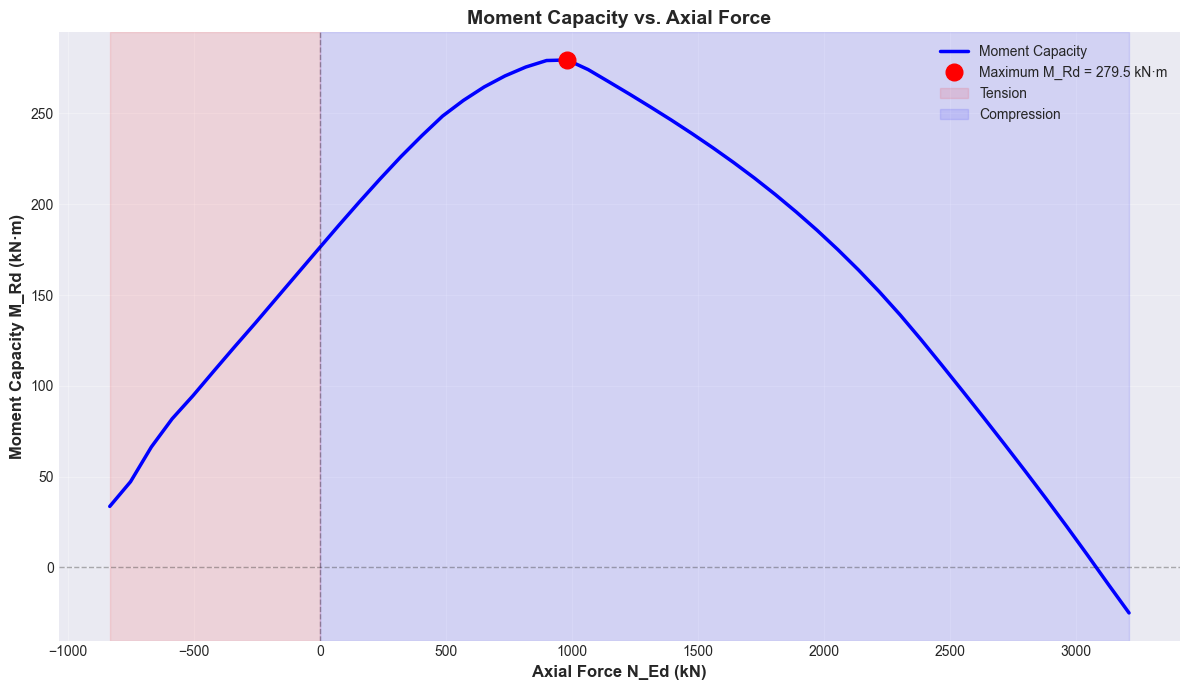

In [29]:
# Create capacity envelope plot
plt.figure(figsize=(12, 7))

# Generate detailed N values within valid range
N_detailed = np.linspace(N_min_valid, N_max_valid, 50)

# Get moment capacities, filtering out None values
M_capacities = []
N_valid = []
for N_Ed in N_detailed:
    N_cap, M_Rd_pos, M_Rd_neg = diagram.get_capacity_fixed_n(N_Ed)
    if M_Rd_pos is not None:
        M_capacities.append(M_Rd_pos)
        N_valid.append(N_cap)

# Find maximum from the plotted data
M_capacities_array = np.array(M_capacities)
N_valid_array = np.array(N_valid)
max_idx = np.argmax(M_capacities_array)
N_at_max_M_plot = N_valid_array[max_idx]
max_M_plot = M_capacities_array[max_idx]

plt.plot(N_valid, M_capacities, 'b-', linewidth=2.5, label='Moment Capacity')
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)

# Mark maximum (using the actual maximum from the plotted curve)
plt.plot(N_at_max_M_plot, max_M_plot, 'ro', markersize=12, label=f'Maximum M_Rd = {max_M_plot:.1f} kN·m', zorder=5)

# Shade compression and tension regions (using valid range)
plt.axvspan(N_min_valid, 0, alpha=0.1, color='red', label='Tension')
plt.axvspan(0, N_max_valid, alpha=0.1, color='blue', label='Compression')

plt.xlabel('Axial Force N_Ed (kN)', fontsize=12, fontweight='bold')
plt.ylabel('Moment Capacity M_Rd (kN·m)', fontsize=12, fontweight='bold')
plt.title('Moment Capacity vs. Axial Force', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Compare Different Concrete Models <a id='compare-concrete'></a>

Compare the two EC2 design concrete stress-strain models:
- **Parabola-Rectangle** (EC2 Fig 3.3): Most accurate, recommended for design
- **Bilinear** (EC2 Fig 3.4): Simplified, slightly conservative

Note: The Schematic model (EC2 Fig 3.2) is not included in this comparison because it uses mean strengths (f_cm) for analysis purposes, while the other models use design strengths (f_cd) for ultimate limit state design.

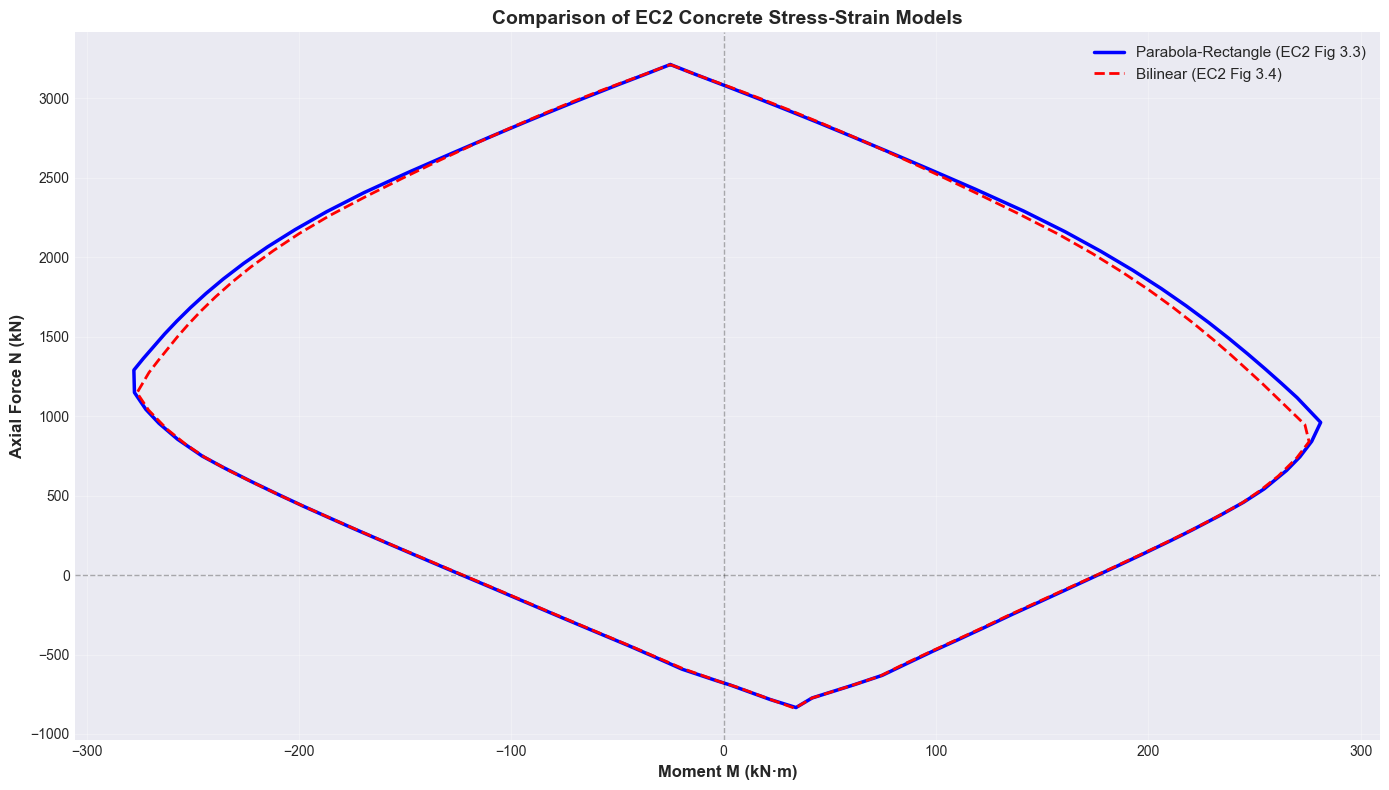


Moment capacity at N = 1000 kN:
  Parabola-Rectangle: 1000.00 kN·m (reference)
  Bilinear: 1000.00 kN·m (+0.0%)


In [30]:
# Create diagrams with different concrete models
diagram_parabola = create_interaction_diagram(
    section=section,
    concrete=concrete,
    concrete_model_type="parabola-rectangle",
    steel_branch_type="inclined",
)

diagram_bilinear = create_interaction_diagram(
    section=section,
    concrete=concrete,
    concrete_model_type="bilinear",
    steel_branch_type="inclined",
)

# Generate curves
N_para, M_para = diagram_parabola.get_diagram_arrays(n_points=100)
N_bili, M_bili = diagram_bilinear.get_diagram_arrays(n_points=100)

# Plot comparison
plt.figure(figsize=(14, 8))
plt.plot(M_para, N_para, 'b-', linewidth=2.5, label='Parabola-Rectangle (EC2 Fig 3.3)')
plt.plot(M_bili, N_bili, 'r--', linewidth=2, label='Bilinear (EC2 Fig 3.4)')

plt.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3, linewidth=1)

plt.xlabel('Moment M (kN·m)', fontsize=12, fontweight='bold')
plt.ylabel('Axial Force N (kN)', fontsize=12, fontweight='bold')
plt.title('Comparison of EC2 Concrete Stress-Strain Models', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

# Quantitative comparison at N = 1000 kN
N_test = 1000.0
M_para_cap = diagram_parabola.get_capacity_fixed_n(N_test)[0]
M_bili_cap = diagram_bilinear.get_capacity_fixed_n(N_test)[0]

print(f"\nMoment capacity at N = {N_test:.0f} kN:")
print(f"  Parabola-Rectangle: {M_para_cap:.2f} kN·m (reference)")
print(f"  Bilinear: {M_bili_cap:.2f} kN·m ({(M_bili_cap/M_para_cap-1)*100:+.1f}%)")

## 10. Compare Steel Models <a id='compare-steel'></a>

Compare steel post-yield behavior:
- **Inclined branch**: Includes strain hardening (more accurate)
- **Horizontal branch**: Perfectly plastic (conservative)

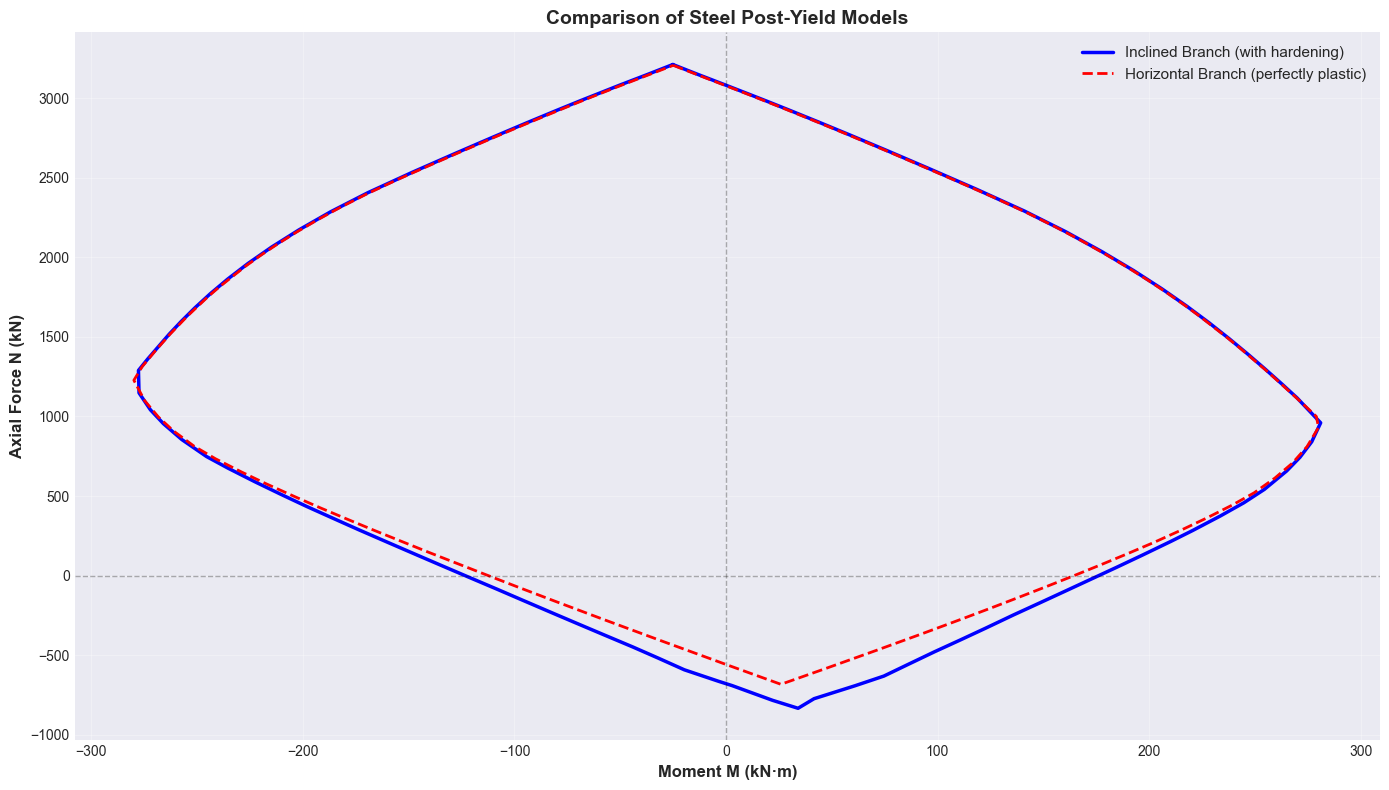


Difference between steel models (at high steel strains):
The inclined branch model accounts for strain hardening, providing
slightly higher capacity in tension-controlled regions where steel
strains exceed the yield strain significantly.


In [31]:
# Create diagrams with different steel models
diagram_inclined = create_interaction_diagram(
    section=section,
    concrete=concrete,
    concrete_model_type="parabola-rectangle",
    steel_branch_type="inclined",
)

diagram_horizontal = create_interaction_diagram(
    section=section,
    concrete=concrete,
    concrete_model_type="parabola-rectangle",
    steel_branch_type="horizontal",
)

# Generate curves
N_incl, M_incl = diagram_inclined.get_diagram_arrays(n_points=100)
N_hori, M_hori = diagram_horizontal.get_diagram_arrays(n_points=100)

# Plot comparison
plt.figure(figsize=(14, 8))
plt.plot(M_incl, N_incl, 'b-', linewidth=2.5, label='Inclined Branch (with hardening)')
plt.plot(M_hori, N_hori, 'r--', linewidth=2, label='Horizontal Branch (perfectly plastic)')

plt.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3, linewidth=1)

plt.xlabel('Moment M (kN·m)', fontsize=12, fontweight='bold')
plt.ylabel('Axial Force N (kN)', fontsize=12, fontweight='bold')
plt.title('Comparison of Steel Post-Yield Models', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

# Quantitative comparison
print("\nDifference between steel models (at high steel strains):")
print("The inclined branch model accounts for strain hardening, providing")
print("slightly higher capacity in tension-controlled regions where steel")
print("strains exceed the yield strain significantly.")

## 11. Effect of Mesh Resolution <a id='mesh-resolution'></a>

Demonstrate how fiber mesh resolution affects accuracy and computation time.

Mesh Resolution Comparison:

    Mesh |   Fibers |   Time (s) |   M_Rd @ N=1000 |    Error
----------------------------------------------------------------------
  Coarse |      155 |      0.217 |         1000.00 |    0.00%
  Medium |      605 |      0.514 |         1000.00 |    0.00%
    Fine |     1505 |      1.108 |         1000.00 |    0.00%


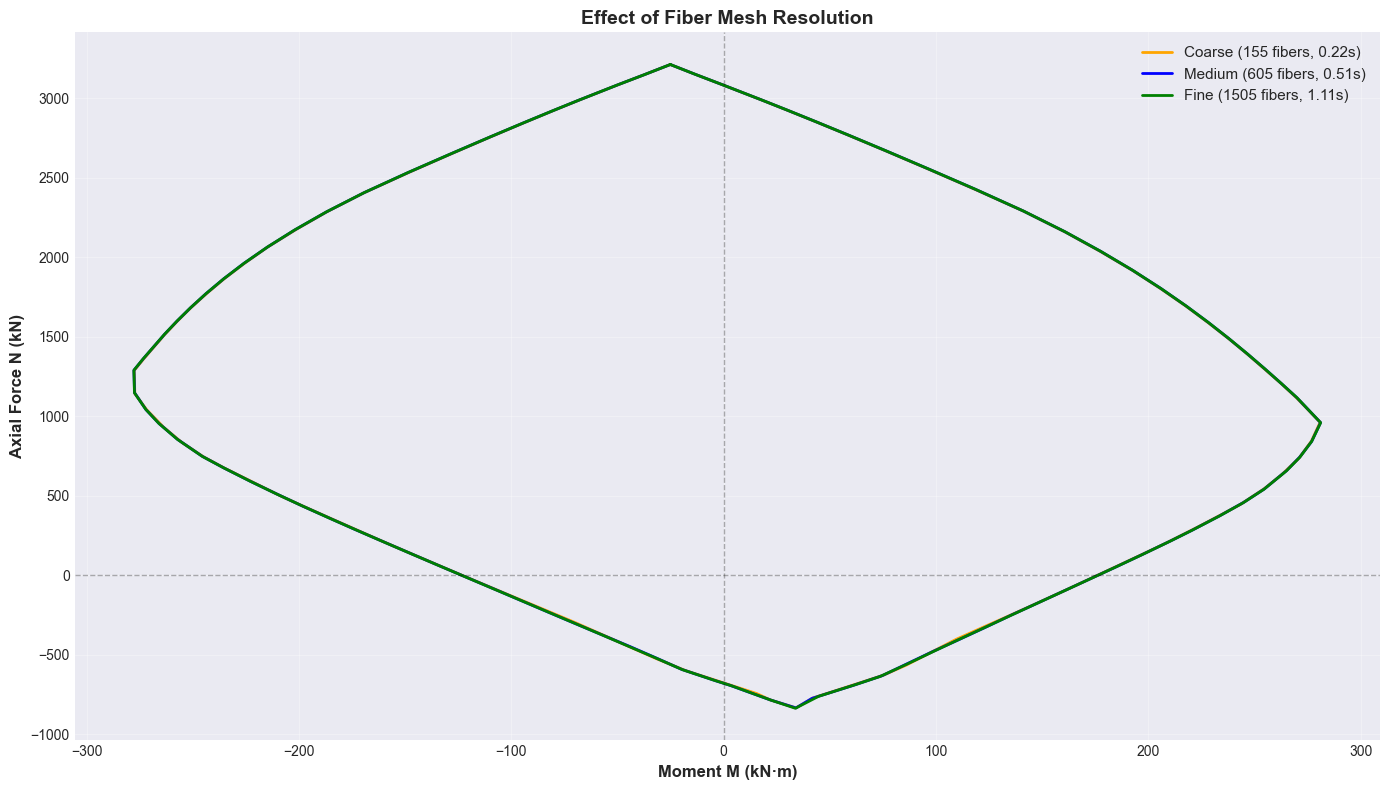

In [32]:
import time

# Test different mesh resolutions
mesh_configs = [
    (10, 15, "Coarse"),
    (20, 30, "Medium"),
    (30, 50, "Fine"),
]

results = []

for n_w, n_h, name in mesh_configs:
    # Create diagram
    start = time.time()
    diag = create_interaction_diagram(
        section=section,
        concrete=concrete,
        n_fibers_width=n_w,
        n_fibers_height=n_h,
    )
    
    # Generate diagram
    N, M = diag.get_diagram_arrays(n_points=100)
    elapsed = time.time() - start
    
    # Get capacity at test point
    M_cap = diag.get_capacity_fixed_n(1000.0)[0]
    
    results.append({
        'name': name,
        'fibers': diag.mesh.total_fibers,
        'time': elapsed,
        'N': N,
        'M': M,
        'M_cap': M_cap,
    })

# Print comparison
print("Mesh Resolution Comparison:\n")
print(f"{'Mesh':>8} | {'Fibers':>8} | {'Time (s)':>10} | {'M_Rd @ N=1000':>15} | {'Error':>8}")
print("-" * 70)

M_ref = results[-1]['M_cap']  # Use finest mesh as reference
for r in results:
    error = abs(r['M_cap'] - M_ref) / M_ref * 100
    print(f"{r['name']:>8} | {r['fibers']:>8} | {r['time']:>10.3f} | {r['M_cap']:>15.2f} | {error:>7.2f}%")

# Plot comparison
plt.figure(figsize=(14, 8))

colors = ['orange', 'blue', 'green']
for r, color in zip(results, colors):
    label = f"{r['name']} ({r['fibers']} fibers, {r['time']:.2f}s)"
    plt.plot(r['M'], r['N'], color=color, linewidth=2, label=label)

plt.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3, linewidth=1)

plt.xlabel('Moment M (kN·m)', fontsize=12, fontweight='bold')
plt.ylabel('Axial Force N (kN)', fontsize=12, fontweight='bold')
plt.title('Effect of Fiber Mesh Resolution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()


## 12. ULS Persistent/Transient vs. Accidental Limit States

Compare M-N interaction diagrams for different ultimate limit state conditions per EN 1992-1-1:

**ULS Persistent/Transient Design:**
- Concrete: γ_c = 1.5, α_cc = 0.85 (standard partial factors)
- Steel: γ_s = 1.15
- Used for normal design situations (dead load, live load, wind, etc.)

**ULS Accidental Design:**
- Concrete: γ_c = 1.2, α_cc = 0.85 (reduced partial factors)  
- Steel: γ_s = 1.0
- Used for exceptional events (seismic, impact, fire aftermath, etc.)
- Higher material strengths allowed due to lower probability of occurrence

In [33]:
# Create materials for both limit states

# ULS Persistent/Transient and ULS Accidental
# handled by different properties in the same material
concrete_example = ConcreteMaterial(
    grade="C30/37",
    gamma_c=1.5,             # Standard partial factor
    gamma_c_accidental=1.2,  # REDUCED partial factor for accidental
    alpha_cc=0.85,           # long-term strength reduction for compressive effects
)

rebar_example = Rebar(
    grade="B500B",
    diameter=20,
    gamma_s=1.15,           # Standard partial factor
    gamma_s_accidental=1.0  # NO partial factor for accidental
)

# Print comparison
print("Material Comparison:\n")
print("CONCRETE:")
print(f"{'Property':<25} | {'Persistent/Transient':>20} | {'Accidental':>15} | {'Difference':>12}")
print("-" * 80)
print(f"{'gamma_c':<25} | {1.5:>20.2f} | {1.2:>15.2f} | {(1.2/1.5-1)*100:>+11.1f}%")
print(f"{'f_cd (MPa)':<25} | {concrete_example.f_cd:>20.2f} | {concrete_example.f_cd_accidental:>15.2f} | {(concrete_example.f_cd_accidental/concrete_example.f_cd-1)*100:>+11.1f}%")
print()

print("STEEL:")
print(f"{'Property':<25} | {'Persistent/Transient':>20} | {'Accidental':>15} | {'Difference':>12}")
print("-" * 80)
print(f"{'gamma_s':<25} | {1.15:>20.2f} | {1.0:>15.2f} | {(1.0/1.15-1)*100:>+11.1f}%")
print(f"{'f_yd (MPa)':<25} | {rebar_example.f_yd:>20.2f} | {rebar_example.f_yd_accidental:>15.2f} | {(rebar_example.f_yd_accidental/rebar_example.f_yd-1)*100:>+11.1f}%")
print()

print("Overall effect: Accidental limit state has ~25% higher concrete design")
print("strength and ~15% higher steel design strength, resulting in significantly")
print("higher section capacity.")

Material Comparison:

CONCRETE:
Property                  | Persistent/Transient |      Accidental |   Difference
--------------------------------------------------------------------------------
gamma_c                   |                 1.50 |            1.20 |       -20.0%
f_cd (MPa)                |                17.00 |           21.25 |       +25.0%

STEEL:
Property                  | Persistent/Transient |      Accidental |   Difference
--------------------------------------------------------------------------------
gamma_s                   |                 1.15 |            1.00 |       -13.0%
f_yd (MPa)                |               434.78 |          500.00 |       +15.0%

Overall effect: Accidental limit state has ~25% higher concrete design
strength and ~15% higher steel design strength, resulting in significantly
higher section capacity.


In [34]:
# Create M-N diagrams for both limit states using the same section geometry

# Use the same section defined earlier in the tutorial
# We'll create two diagrams with different material design properties
# (because they use different factors)

# ULS Persistent/Transient diagram
diagram_persistent = create_interaction_diagram(
    section=section,  # Same 300x500 beam from earlier
    concrete=concrete_example,
    concrete_model_type="parabola-rectangle",
    steel_branch_type="inclined",
    n_fibers_width=20,
    n_fibers_height=30,
    use_accidental=False
)

# ULS Accidental diagram
diagram_accidental = create_interaction_diagram(
    section=section,  # Same section geometry
    concrete=concrete_example,
    concrete_model_type="parabola-rectangle",
    steel_branch_type="inclined",
    n_fibers_width=20,
    n_fibers_height=30,
    use_accidental=True
)

# Generate M-N curves
print("Generating M-N diagrams for both limit states...")
N_pers, M_pers = diagram_persistent.get_diagram_arrays(n_points=100)
N_acc, M_acc = diagram_accidental.get_diagram_arrays(n_points=100)

print(f"[OK] Persistent/Transient: {len(N_pers)} points")
print(f"[OK] Accidental: {len(N_acc)} points")
print()

# Find key capacities for comparison
M_pers_max = np.max(M_pers)
M_acc_max = np.max(M_acc)
N_pers_max = np.max(N_pers)
N_acc_max = np.max(N_acc)
N_pers_min = np.min(N_pers)
N_acc_min = np.min(N_acc)

print("Capacity Comparison:")
print(f"  Maximum Moment:")
print(f"    Persistent/Transient: {M_pers_max:.1f} kN·m")
print(f"    Accidental: {M_acc_max:.1f} kN·m ({(M_acc_max/M_pers_max-1)*100:+.1f}%)")
print()
print(f"  Pure Compression:")
print(f"    Persistent/Transient: {N_pers_max:.0f} kN")
print(f"    Accidental: {N_acc_max:.0f} kN ({(N_acc_max/N_pers_max-1)*100:+.1f}%)")
print()
print(f"  Pure Tension:")
print(f"    Persistent/Transient: {N_pers_min:.0f} kN")
print(f"    Accidental: {N_acc_min:.0f} kN ({(N_acc_min/N_pers_min-1)*100:+.1f}%)")

Generating M-N diagrams for both limit states...
[OK] Persistent/Transient: 100 points
[OK] Accidental: 100 points

Capacity Comparison:
  Maximum Moment:
    Persistent/Transient: 281.1 kN·m
    Accidental: 334.7 kN·m (+19.1%)

  Pure Compression:
    Persistent/Transient: 3211 kN
    Accidental: 3941 kN (+22.7%)

  Pure Tension:
    Persistent/Transient: -834 kN
    Accidental: -820 kN (-1.7%)


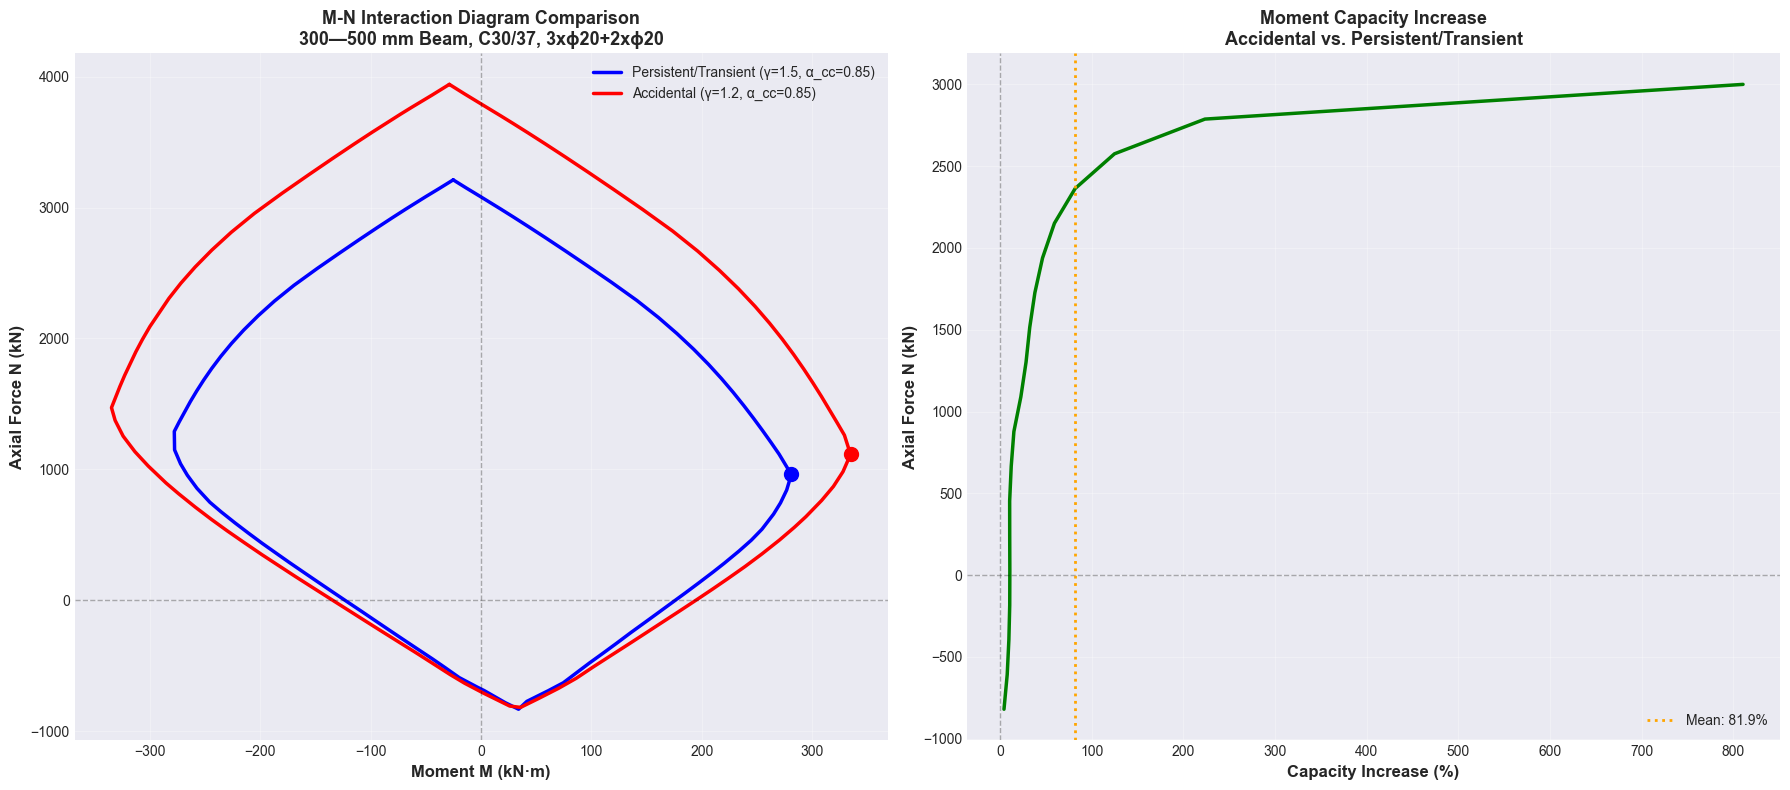


Statistics of capacity increase (Accidental vs. Persistent/Transient):
  Mean increase: 81.9%
  Min increase: 4.2%
  Max increase: 810.5%

This demonstrates that accidental limit state design allows significantly
higher section capacity across all load combinations, typically 30-40% more
moment capacity for the same section.


In [35]:
# Create side-by-side comparison plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left plot: Overlaid M-N curves
ax1 = axes[0]
ax1.plot(M_pers, N_pers, 'b-', linewidth=2.5, label='Persistent/Transient (γ=1.5, α_cc=0.85)')
ax1.plot(M_acc, N_acc, 'r-', linewidth=2.5, label='Accidental (γ=1.2, α_cc=0.85)')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3, linewidth=1)

# Mark key points on both curves
ax1.plot(M_pers_max, N_pers[np.argmax(M_pers)], 'bo', markersize=10, zorder=5)
ax1.plot(M_acc_max, N_acc[np.argmax(M_acc)], 'ro', markersize=10, zorder=5)

ax1.set_xlabel('Moment M (kN·m)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Axial Force N (kN)', fontsize=12, fontweight='bold')
ax1.set_title('M-N Interaction Diagram Comparison\n300—500 mm Beam, C30/37, 3xϕ20+2xϕ20',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=10)

# Right plot: Capacity increase percentage
# Calculate capacity ratio at different N levels
N_test_levels = np.linspace(max(N_pers_min, N_acc_min), min(N_pers_max, N_acc_max), 20)
capacity_ratios = []
N_plot = []

for N_test in N_test_levels:
    M_pers_at_N = diagram_persistent.get_capacity_fixed_n(N_test)[1]  # [1] for M_Rd_pos
    M_acc_at_N = diagram_accidental.get_capacity_fixed_n(N_test)[1]   # [1] for M_Rd_pos
    
    if M_pers_at_N is not None and M_acc_at_N is not None and M_pers_at_N > 0:
        ratio = (M_acc_at_N / M_pers_at_N - 1) * 100  # Percentage increase
        capacity_ratios.append(ratio)
        N_plot.append(N_test)

ax2 = axes[1]
ax2.plot(capacity_ratios, N_plot, 'g-', linewidth=2.5)
ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)

# Shade the typical range
mean_increase = np.mean(capacity_ratios)
ax2.axvline(x=mean_increase, color='orange', linestyle=':', linewidth=2, 
           label=f'Mean: {mean_increase:.1f}%')

ax2.set_xlabel('Capacity Increase (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Axial Force N (kN)', fontsize=12, fontweight='bold')
ax2.set_title('Moment Capacity Increase\nAccidental vs. Persistent/Transient',
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nStatistics of capacity increase (Accidental vs. Persistent/Transient):")
print(f"  Mean increase: {mean_increase:.1f}%")
print(f"  Min increase: {min(capacity_ratios):.1f}%")
print(f"  Max increase: {max(capacity_ratios):.1f}%")
print()
print("This demonstrates that accidental limit state design allows significantly")
print("higher section capacity across all load combinations, typically 30-40% more")
print("moment capacity for the same section.")

## 13. Advanced: T-Beam Section <a id='t-beam'></a>

Demonstrate M-N diagram for a non-rectangular section using Shapely polygons.

T-Beam Section: T-Beam Example
  Web: 200mm wide — 400mm deep (centred)
  Flange: 500mm wide — 100mm deep
  Gross area: 130000 mm²

Reinforcement: 2463 mm²
  Bottom: 4xϕ•20 = 1257 mm² (in web)
  Top: 6xϕ•16 = 1206 mm² (in flange)

MNInteractionDiagram(section=T-Beam Example, concrete=C30/37, fibers=424, tension_stiffening=False, confined=False)



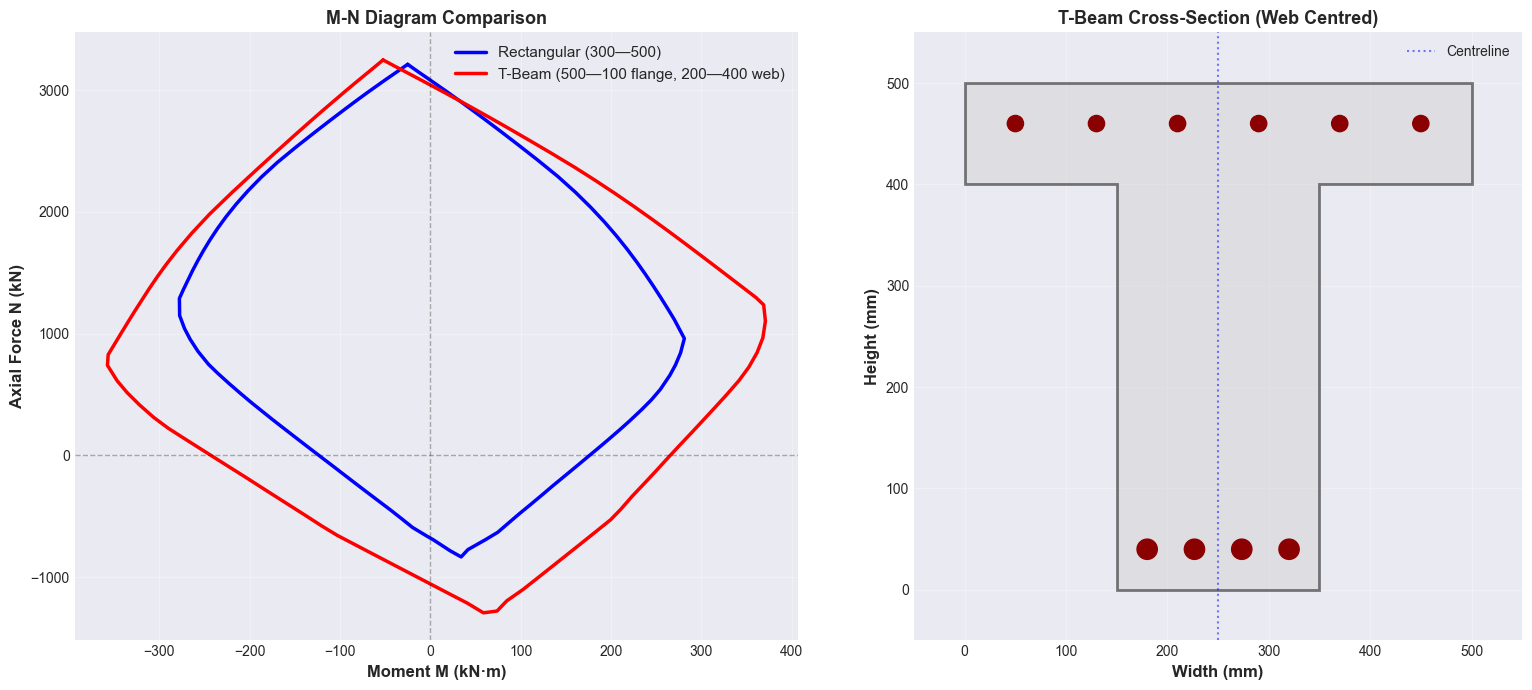

Comparison Summary:
  Maximum Moment:
    Rectangular: 281.1 kN·m
    T-Beam: 370.8 kN·m (+31.9%)
  Pure Compression:
    Rectangular: 3211 kN
    T-Beam: 3247 kN (+1.1%)

Note: The T-beam has significantly higher moment capacity due to the wide
      compression flange providing a larger compression block lever arm.


In [36]:
# Create T-beam geometry
# Web: 200mm wide — 400mm deep, centred under flange
# Flange: 500mm wide — 100mm deep
# Web is centred: flange is 500mm wide, so web spans from 150mm to 350mm (centred at 250mm)

t_beam_coords = [
    (150, 0),      # Bottom left of web
    (350, 0),      # Bottom right of web
    (350, 400),    # Top right of web (bottom of flange)
    (500, 400),    # Flange right edge
    (500, 500),    # Top right of flange
    (0, 500),      # Top left of flange
    (0, 400),      # Flange left edge
    (150, 400),    # Top left of web (bottom of flange)
]

t_beam = RCSection(
    outline=Polygon(t_beam_coords),
    section_name="T-Beam Example",
)

print(f"T-Beam Section: {t_beam.section_name}")
print(f"  Web: 200mm wide — 400mm deep (centred)")
print(f"  Flange: 500mm wide — 100mm deep")
print(f"  Gross area: {t_beam.get_area():.0f} mm²")
print()

# Add reinforcement
# Bottom: 4Ã—Ï•20 (tension) - centred in web
bottom_t = create_linear_rebar_layer(
    rebar=rebar_20,
    n_bars=4,
    start_point=(180, 40),
    end_point=(320, 40),
    layer_name="bottom",
)
t_beam.add_rebar_group(bottom_t)

# Top flange: 6Ã—Ï•16 (compression) - distributed across flange
rebar_16 = Rebar(grade="B500B", diameter=16)
top_t = create_linear_rebar_layer(
    rebar=rebar_16,
    n_bars=6,
    start_point=(50, 460),
    end_point=(450, 460),
    layer_name="top",
)
t_beam.add_rebar_group(top_t)

print(f"Reinforcement: {t_beam.total_steel_area:.0f} mm²")
print(f"  Bottom: 4xϕ•20 = {bottom_t.total_area:.0f} mm² (in web)")
print(f"  Top: 6xϕ•16 = {top_t.total_area:.0f} mm² (in flange)")
print()

# Create M-N diagram for T-beam
diagram_t = create_interaction_diagram(
    section=t_beam,
    concrete=concrete,
    concrete_model_type="parabola-rectangle",
    steel_branch_type="inclined",
    n_fibers_width=25,
    n_fibers_height=30,
)

print(diagram_t)
print()

# Generate curves for both sections
N_rect, M_rect = diagram.get_diagram_arrays(n_points=100)
N_t, M_t = diagram_t.get_diagram_arrays(n_points=100)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: M-N diagram comparison
ax1.plot(M_rect, N_rect, 'b-', linewidth=2.5, label='Rectangular (300—500)')
ax1.plot(M_t, N_t, 'r-', linewidth=2.5, label='T-Beam (500—100 flange, 200—400 web)')
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
ax1.set_xlabel('Moment M (kN·m)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Axial Force N (kN)', fontsize=12, fontweight='bold')
ax1.set_title('M-N Diagram Comparison', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=11)

# Right: Section visualization
from matplotlib.patches import Polygon as MPLPolygon

# Draw T-beam outline
t_patch = MPLPolygon(t_beam_coords, fill=True, facecolor='lightgray', 
                     edgecolor='black', linewidth=2, alpha=0.5)
ax2.add_patch(t_patch)

# Draw rebars
for group in t_beam.rebar_groups:
    for pos in group.positions:
        circle = plt.Circle((pos.x, pos.y), group.rebar.diameter/2, 
                           color='darkred', zorder=5)
        ax2.add_patch(circle)

# Add centerline to show symmetry
ax2.axvline(x=250, color='blue', linestyle=':', linewidth=1.5, alpha=0.5, label='Centreline')

ax2.set_xlim(-50, 550)
ax2.set_ylim(-50, 550)
ax2.set_aspect('equal')
ax2.set_xlabel('Width (mm)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Height (mm)', fontsize=12, fontweight='bold')
ax2.set_title('T-Beam Cross-Section (Web Centred)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Quantitative comparison
M_rect_max = np.max(M_rect)
M_t_max = np.max(M_t)
N_rect_max = np.max(N_rect)
N_t_max = np.max(N_t)

print("Comparison Summary:")
print(f"  Maximum Moment:")
print(f"    Rectangular: {M_rect_max:.1f} kN·m")
print(f"    T-Beam: {M_t_max:.1f} kN·m ({(M_t_max/M_rect_max-1)*100:+.1f}%)")
print(f"  Pure Compression:")
print(f"    Rectangular: {N_rect_max:.0f} kN")
print(f"    T-Beam: {N_t_max:.0f} kN ({(N_t_max/N_rect_max-1)*100:+.1f}%)")
print()
print("Note: The T-beam has significantly higher moment capacity due to the wide")
print("      compression flange providing a larger compression block lever arm.")

## Summary

This tutorial demonstrated the complete M-N interaction diagram functionality:

### Key Functions:

1. **`create_interaction_diagram()`** - Initialize diagram with section and materials
2. **`calculate_point(NA_depth)`** - Calculate single (N, M) point at neutral axis depth
3. **`generate_diagram(n_points)`** - Generate complete M-N curve
4. **`get_diagram_arrays(n_points)`** - Export as NumPy arrays for plotting
5. **`get_utilization_vector(N_Ed, M_Ed)`** - Check capacity using vector projection method
6. **`get_capacity_fixed_n(N_Ed)`** - Find moment capacity at fixed axial force

### Features Demonstrated:

- Fiber-based strain compatibility analysis per EC2
- Multiple concrete models (parabola-rectangle, bilinear, schematic)
- Steel strain hardening options
- Capacity checking and utilization ratios
- Arbitrary section shapes with Shapely
- Mesh resolution control
- Complete visualization examples

### Applications:

- Design of RC sections under combined axial force and bending
- FEA post-processing and code checking
- Capacity verification for existing structures
- Parametric studies and optimization
- Teaching and learning structural design

For more information, see:
- `M-N_DIAGRAM_IMPLEMENTATION.md` - Detailed implementation documentation
- `README.md` - Library overview
- EN 1992-1-1:2004 (Eurocode 2) - Code reference